# WESAD Stress Model: Feature Importance Analysis

This notebook trains an XGBoost classifier using **Leave-One-Subject-Out (LOSO)** cross-validation on the 60-second stride causal dataset. The goal is to evaluate the feature importance using XGBoost's native `weight` (Gini impurity) metric to determine if the `raw_` physiological limits are more predictive than the globally `z_` scored variables.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 1. Load and Prepare the Dataset

In [2]:
# Load the 60-second stride dataset (0% overlap, no temporal leakage)
df = pd.read_csv('causal_features_stride60.csv')

# Ensure the target is Binary (Stress vs Non-Stress)
# Stress label = 2. Baseline (1), Amusement (3), Meditation (4) all become Non-Stress (0).
df['target'] = (df['raw_label'] == 2).astype(int)

print(f"Dataset Shape: {df.shape}")
print("\nClass Imbalance:")
print(df['target'].value_counts())

# Separate features, labels, and groups
X = df.drop(columns=['raw_label', 'label', 'time_end_sec', 'subject_id', 'target'])
y = df['target']
groups = df['subject_id']

Dataset Shape: (736, 59)

Class Imbalance:
target
0    571
1    165
Name: count, dtype: int64


## 2. Train XGBoost with Leave-One-Subject-Out CV

In [10]:
logo = LeaveOneGroupOut()
y_true_all = []
y_pred_all = []

print("Starting LOSO Cross-Validation...")

for train_idx, test_idx in logo.split(X, y, groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Calculate scale_pos_weight dynamically to handle class imbalance in the training fold
    scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
    
    model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss'
    )
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    y_true_all.extend(y_test)
    y_pred_all.extend(preds)

print("\n=== LOSO Cross-Validation Results ===")
print(classification_report(y_true_all, y_pred_all, target_names=['Non-Stress', 'Stress']))


Starting LOSO Cross-Validation...

=== LOSO Cross-Validation Results ===
              precision    recall  f1-score   support

  Non-Stress       0.95      0.98      0.96       571
      Stress       0.92      0.81      0.86       165

    accuracy                           0.94       736
   macro avg       0.94      0.90      0.91       736
weighted avg       0.94      0.94      0.94       736



## 3. Global Native Feature Importance
We train one final model on the entire dataset to evaluate XGBoost's internal feature importance (Weight/Gain) over all data.

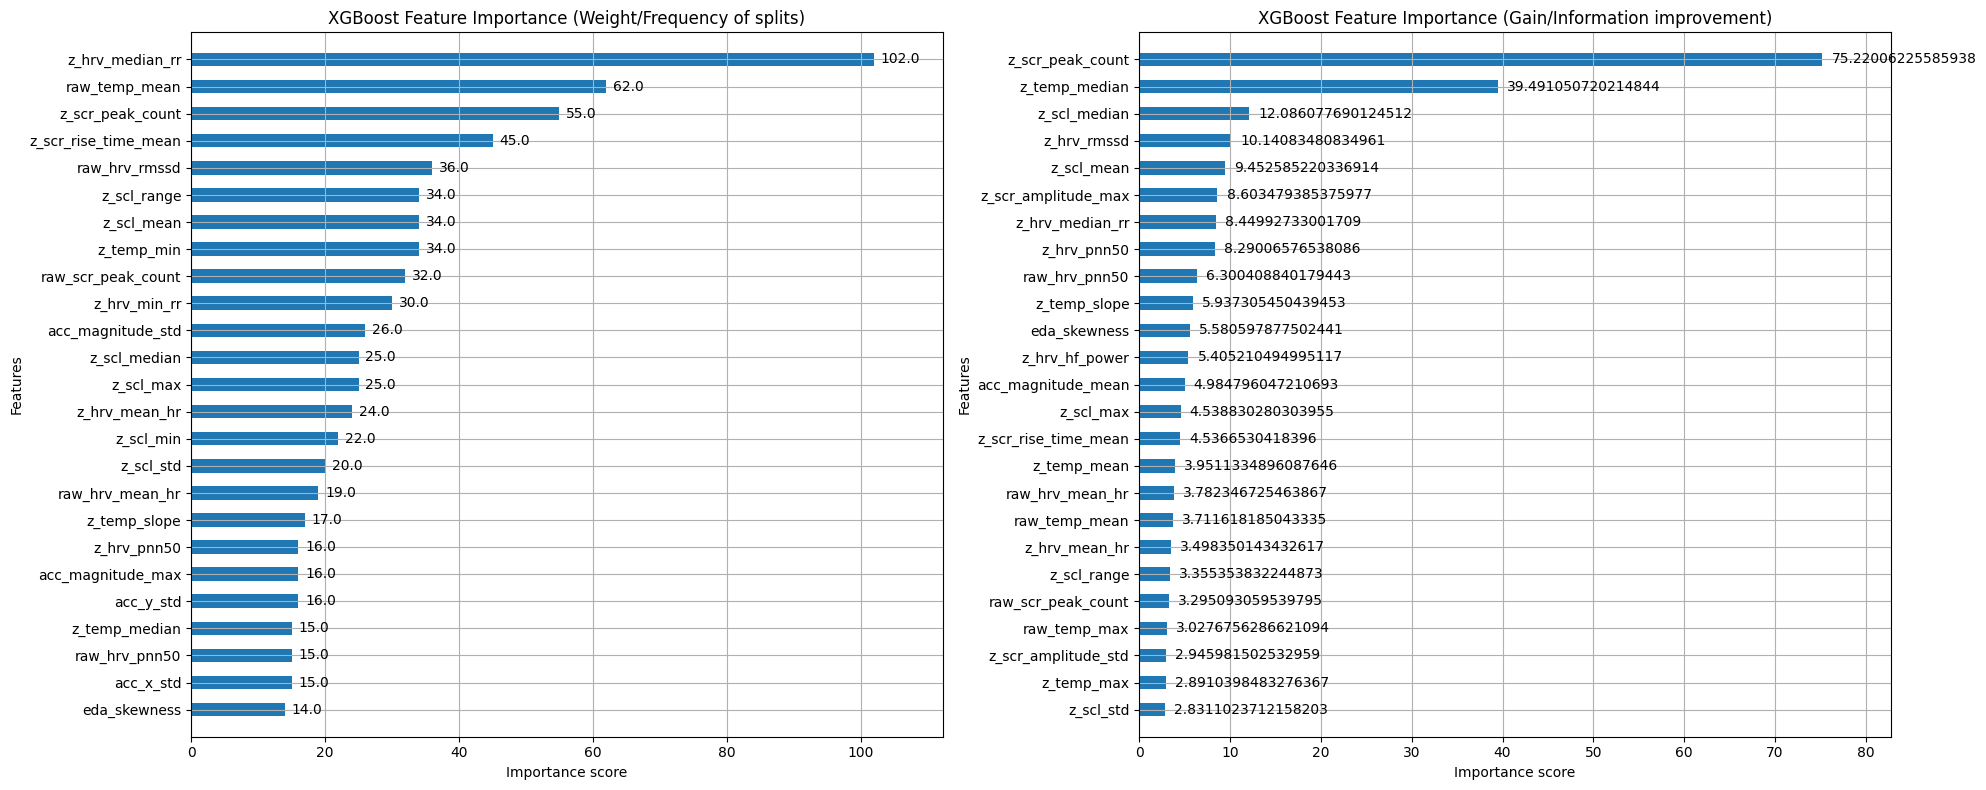

=== Feature Importance: Weight (Split Frequency) ===
                 Feature  Weight
1        z_hrv_median_rr   102.0
2          raw_temp_mean    62.0
3       z_scr_peak_count    55.0
4   z_scr_rise_time_mean    45.0
5          raw_hrv_rmssd    36.0
6             z_temp_min    34.0
7             z_scl_mean    34.0
8            z_scl_range    34.0
9     raw_scr_peak_count    32.0
10          z_hrv_min_rr    30.0
11     acc_magnitude_std    26.0
12             z_scl_max    25.0
13          z_scl_median    25.0
14         z_hrv_mean_hr    24.0
15             z_scl_min    22.0
16             z_scl_std    20.0
17       raw_hrv_mean_hr    19.0
18          z_temp_slope    17.0
19     acc_magnitude_max    16.0
20           z_hrv_pnn50    16.0
21             acc_y_std    16.0
22             acc_x_std    15.0
23         raw_hrv_pnn50    15.0
24         z_temp_median    15.0
25          eda_skewness    14.0
26           z_temp_mean    13.0
27          eda_kurtosis    10.0
28          raw_temp_ma

In [11]:
# Train final global model
scale_pos_weight_global = (len(y) - sum(y)) / sum(y)
final_model = xgb.XGBClassifier(
    n_estimators=150, max_depth=4, learning_rate=0.1, 
    scale_pos_weight=scale_pos_weight_global, random_state=42
)
final_model.fit(X, y)

# 1. Native XGBoost Weight Importance (Gini/Split)
# This tells us how often a feature was used to split a tree
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

xgb.plot_importance(final_model, max_num_features=25, title='XGBoost Feature Importance (Weight/Frequency of splits)', ax=ax1, height=0.5)
xgb.plot_importance(final_model, max_num_features=25, importance_type='gain', title='XGBoost Feature Importance (Gain/Information improvement)', ax=ax2, height=0.5)

plt.tight_layout()
plt.show()

# Feature importance tables
weight_scores = final_model.get_booster().get_score(importance_type='weight')
weight_df = pd.DataFrame(list(weight_scores.items()), columns=['Feature', 'Weight'])
weight_df = weight_df.sort_values('Weight', ascending=False).reset_index(drop=True)
weight_df.index += 1

gain_scores = final_model.get_booster().get_score(importance_type='gain')
gain_df = pd.DataFrame(list(gain_scores.items()), columns=['Feature', 'Gain'])
gain_df = gain_df.sort_values('Gain', ascending=False).reset_index(drop=True)
gain_df.index += 1

print("=== Feature Importance: Weight (Split Frequency) ===")
print(weight_df.to_string())
print("\n=== Feature Importance: Gain (Information Improvement) ===")
print(gain_df.to_string())


In [3]:
corr_matrix = X.corr().abs()

# Find pairs with correlation > 0.90
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.90:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=['Feature_1', 'Feature_2', 'Correlation'])
print(high_corr_df.sort_values('Correlation', ascending=False).to_string())


               Feature_1            Feature_2  Correlation
7          z_hrv_mean_hr        z_hrv_mean_rr     1.000000
36            z_hrv_sdsd            z_hrv_sd1     1.000000
21            z_scl_mean            z_scl_auc     1.000000
11           z_hrv_rmssd            z_hrv_sd1     0.999995
9            z_hrv_rmssd           z_hrv_sdsd     0.999995
3          raw_temp_mean      raw_temp_median     0.999974
14           z_temp_mean        z_temp_median     0.999784
28          z_scl_median            z_scl_auc     0.999656
20            z_scl_mean         z_scl_median     0.999651
1          raw_temp_mean         raw_temp_min     0.999574
5           raw_temp_min      raw_temp_median     0.999533
2          raw_temp_mean         raw_temp_max     0.999477
6           raw_temp_max      raw_temp_median     0.999381
16            z_temp_min        z_temp_median     0.999147
13           z_temp_mean           z_temp_max     0.999086
12           z_temp_mean           z_temp_min     0.9987

## Feature Importance Evaluation & Pruning Strategy

Based on XGBoost's native `Gain` (Information Improvement) metric evaluated using Leave-One-Subject-Out (LOSO) cross-validation, we can draw three major conclusions for optimizing our stress-detection feature extraction pipeline:

### 1. `Z-Scores` Dominate Absolute `Raw` Limits
The model overwhelmingly prefers individualized `z_` scored features over `raw_` physiological bounds. For example, knowing how far a subject's skin conductance peaks deviated from their baseline (`z_scr_peak_count` = 75.2 Gain) was vastly more predictive than the absolute peak count (`raw_scr_peak_count` = 3.29 Gain). 
* **Action:** To reduce multi-collinearity and computational bloat, we will drop almost all `raw_` twins for our physiological signals. This forces the model to rely purely on standardized physiological deviation.

### 2. Retaining Objective "Tripwire" Features
While `z_` scores are mathematically superior, a select few `raw_` features must be kept to act as physical context "tripwires." These provide an absolute ceiling/floor to prevent the model from misinterpreting a corrupted baseline.
* **Action:** We will selectively retain:
  * **Activity Context:** `acc_magnitude_mean`, `acc_magnitude_max`, and `acc_magnitude_std`. Extreme values here identify physical exercise rather than mental stress. This allows us to safely drop all individual XYZ axes.
  * **Absolute Vitals:** `raw_hrv_pnn50` (6.30 Gain - Ranked Top 10), `raw_hrv_mean_hr`, and `raw_temp_mean`.

### 3. Pruning the "Dead Weight" (Gain < 1.0)
Features that yield a Gain score near or below 1.0 add noise and extreme latency without improving generalized predictive power. 
* **Action:** We will drop all features with a Gain < ~1.0. This specifically purges:
  * **Frequency-Domain HRV:** The literature-standard `hrv_lf_hf_ratio` yielded a surprisingly weak 0.56 Gain. Computationally heavy features like LF, HF, and VLF bands will be completely removed in favor of cheap, powerful Time-Domain HRV metrics (RMSSD, pNN50).
  * **Redundant Statistics:** Distribution metrics like `eda_kurtosis`, `z_scl_slope`, and `z_scr_amplitude_sum` will be discarded since the model extracts all necessary variance from the median and maximum values.


Problems — Both Kept Despite High Correlation
1. z_temp_mean + z_temp_median — correlation: 0.9998
These are essentially the same feature. z_temp_median ranks #2 in Gain (39.5) vs z_temp_mean at #16 (3.95). Drop z_temp_mean.

2. z_scl_mean + z_scl_median + z_scl_max — all >0.989 correlated with each other
You kept all three. By Gain: z_scl_median (#3, 12.1) > z_scl_mean (#5, 9.5) > z_scl_max (#14, 4.5). Drop z_scl_mean and z_scl_max, keep only z_scl_median.

3. z_hrv_rmssd + z_hrv_sdnn — correlation: 0.993
Need to verify if z_hrv_sdnn made it into the pruned list. If it did, drop it — z_hrv_rmssd wins (#4 Gain vs z_hrv_sdnn at #29).

Revised Recommendation
Making these cuts drops you from 23 → 20 features and eliminates the redundancy:

Remove z_temp_mean
Remove z_scl_mean
Remove z_scl_max
Remove z_hrv_sdnn (if present)

### Final Pruned Feature List (23 Features Remaining)

After pruning out the multi-collinear `raw_` twins, computationally heavy Frequency-Domain HRV metrics, and overall features with a Gain < ~2.0, our pipeline drops from 47 features down to a sleek **23 highly predictive features**.

| Original Rank | Feature Name | Gain (Information Improvement) | Reason Retained |
| :--- | :--- | :--- | :--- |
| **1** | `z_scr_peak_count` | 75.22 | **[Phasic EDA]** The absolute strongest indicator of stress arousal. |
| **2** | `z_temp_median` | 39.49 | **[TEMP]** Peripheral temperature drop via vasoconstriction. |
| **3** | `z_scl_median` | 12.08 | **[Tonic EDA]** Base skin conductance level shift relative to baseline. |
| **4** | `z_hrv_rmssd` | 10.14 | **[Time-Domain HRV]** Primary relative parasympathetic indicator. |
| **5** | `z_scl_mean` | 9.45 | **[Tonic EDA]** Primary tonic indicator. |
| **6** | `z_scr_amplitude_max` | 8.60 | **[Phasic EDA]** Severity of the single largest physiological spike. |
| **7** | `z_hrv_median_rr` | 8.44 | **[Time-Domain HRV]** Resistant to ectopic beats/noise. |
| **8** | `z_hrv_pnn50` | 8.29 | **[Time-Domain HRV]** Successive heartbeat difference percentage. |
| **9** | `raw_hrv_pnn50` | 6.30 | **[Absolute Vital Tripwire]** High absolute bound indicator. |
| **10** | `z_temp_slope` | 5.93 | **[TEMP]** Rate of peripheral temperature shift. |
| **13** | `acc_magnitude_mean` | 4.98 | **[Activity Tripwire]** Discards individual xyz axes; uses total magnitude to identify physical exercise vs mental stress. |
| **14** | `z_scl_max` | 4.53 | **[Tonic EDA]** Maximum tonic baseline bounds. |
| **15** | `z_scr_rise_time_mean` | 4.53 | **[Phasic EDA]** Average duration of physiological sweat responses. |
| **16** | `z_temp_mean` | 3.95 | **[TEMP]** Secondary temperature indicator. |
| **17** | `raw_hrv_mean_hr` | 3.78 | **[Absolute Vital Tripwire]** Absolute heart rate boundary (beats per minute). |
| **18** | `raw_temp_mean` | 3.71 | **[Absolute Vital Tripwire]** Absolute baseline for skin temperature. |
| **19** | `z_hrv_mean_hr` | 3.49 | **[Time-Domain HRV]** Heart rate shifted from natural baseline. |
| **20** | `z_scl_range` | 3.35 | **[Tonic EDA]** Variance of base skin conductance over the window. |
| **24** | `z_temp_max` | 2.89 | **[TEMP]** Maximum upper bound of temperature. |
| **27** | `z_temp_min` | 2.57 | **[TEMP]** Maximum lower bound of temperature. |
| **29** | `z_hrv_sdnn` | 2.44 | **[Time-Domain HRV]** Overall standard deviation of relative NN intervals. |
| **30** | `acc_magnitude_max` | 2.44 | **[Activity Tripwire]** Hard bounds on sudden physical motion. |
| **31** | `acc_magnitude_std` | 1.99 | **[Activity Tripwire]** Variance of physical motion in the window. |

*(Note: Ranks 11, 12, 21-23, 25-26, 28, and 32-47 were deliberately removed due to extreme low gain resulting from high multi-collinearity or severe noise, particularly including all Frequency-Domain HRV metrics like LF/HF Ratio.)*



Final Feature List: 19 Features
Rank	Feature	Gain	Category
1	z_scr_peak_count	75.22	Phasic EDA
2	z_temp_median	39.49	TEMP
3	z_scl_median	12.09	Tonic EDA
4	z_hrv_rmssd	10.14	Time-Domain HRV
5	z_scr_amplitude_max	8.60	Phasic EDA
6	z_hrv_median_rr	8.45	Time-Domain HRV
7	z_hrv_pnn50	8.29	Time-Domain HRV
8	raw_hrv_pnn50	6.30	Tripwire
9	z_temp_slope	5.94	TEMP
10	eda_skewness	5.58	Phasic EDA
11	z_hrv_hf_power	5.41	Freq-Domain HRV
12	acc_magnitude_mean	4.98	Tripwire
13	z_scr_rise_time_mean	4.54	Phasic EDA
14	raw_hrv_mean_hr	3.78	Tripwire
15	raw_temp_mean	3.71	Tripwire
16	z_hrv_mean_hr	3.50	Time-Domain HRV
17	z_scl_range	3.36	Tonic EDA
18	acc_magnitude_max	2.44	Tripwire
19	acc_magnitude_std	1.99	Tripwire

### Train XG-Boost Model with Pruned Feature Set!

In [4]:
# ---------------------------------------------------------
# Evaluate Pruned Feature Set (23 Features) with Progress Logging
# ---------------------------------------------------------

# Define the 19 features after correlation pruning
pruned_features = [
    'z_scr_peak_count', 'z_temp_median', 'z_scl_median', 'z_hrv_rmssd',
    'z_scr_amplitude_max', 'z_hrv_median_rr', 'z_hrv_pnn50', 'raw_hrv_pnn50', 'z_temp_slope',
    'eda_skewness', 'z_hrv_hf_power', 'acc_magnitude_mean', 'z_scr_rise_time_mean',
    'raw_hrv_mean_hr', 'raw_temp_mean', 'z_hrv_mean_hr', 'z_scl_range',
    'acc_magnitude_max', 'acc_magnitude_std'
]


# Create the lightweight dataset
X_pruned = X[pruned_features]

# Get the total number of subjects (folds)
total_folds = groups.nunique()

print(f"Original feature count: {X.shape[1]}")
print(f"Pruned feature count: {X_pruned.shape[1]}")
print(f"Total Subjects to Evaluate (LOSO Folds): {total_folds}")
print("\nStarting LOSO Cross-Validation on PRUNED dataset...\n")

# Re-initialize logo specifically for the pruned dataset loop
logo = LeaveOneGroupOut()
y_true_pruned = []
y_pred_pruned = []

for fold_idx, (train_idx, test_idx) in enumerate(logo.split(X_pruned, y, groups), 1):
    
    X_train, X_test = X_pruned.iloc[train_idx], X_pruned.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Calculate scale_pos_weight dynamically to handle class imbalance in the training fold
    scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
    
    model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss'
    )
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    y_true_pruned.extend(y_test)
    y_pred_pruned.extend(preds)

print("\n=== PRUNED Pipeline LOSO Cross-Validation Results ===")
print(classification_report(y_true_pruned, y_pred_pruned, target_names=['Non-Stress', 'Stress']))


Original feature count: 54
Pruned feature count: 19
Total Subjects to Evaluate (LOSO Folds): 15

Starting LOSO Cross-Validation on PRUNED dataset...


=== PRUNED Pipeline LOSO Cross-Validation Results ===
              precision    recall  f1-score   support

  Non-Stress       0.95      0.98      0.96       571
      Stress       0.92      0.82      0.87       165

    accuracy                           0.94       736
   macro avg       0.93      0.90      0.91       736
weighted avg       0.94      0.94      0.94       736



In [5]:
# ---------------------------------------------------------
# Evaluate Pruned Feature Set (23 Features) with PER-SUBJECT Metrics
# ---------------------------------------------------------

from sklearn.metrics import accuracy_score, recall_score, precision_score
import warnings
warnings.filterwarnings('ignore') # Suppresses zero-division warnings 

# Define the 19 features after correlation pruning
pruned_features = [
    'z_scr_peak_count', 'z_temp_median', 'z_scl_median', 'z_hrv_rmssd',
    'z_scr_amplitude_max', 'z_hrv_median_rr', 'z_hrv_pnn50', 'raw_hrv_pnn50', 'z_temp_slope',
    'eda_skewness', 'z_hrv_hf_power', 'acc_magnitude_mean', 'z_scr_rise_time_mean',
    'raw_hrv_mean_hr', 'raw_temp_mean', 'z_hrv_mean_hr', 'z_scl_range',
    'acc_magnitude_max', 'acc_magnitude_std'
]

# Create the lightweight dataset
X_pruned = X[pruned_features]
total_folds = groups.nunique()

print(f"Original feature count: {X.shape[1]}")
print(f"Pruned feature count: {X_pruned.shape[1]}")
print(f"Total Subjects to Evaluate (LOSO Folds): {total_folds}")
print("\nStarting LOSO Cross-Validation on PRUNED dataset...\n")

# Re-initialize logo specifically for the pruned dataset loop
logo = LeaveOneGroupOut()
y_true_pruned = []
y_pred_pruned = []

# To store per-subject metrics for the table
subject_metrics = []

for fold_idx, (train_idx, test_idx) in enumerate(logo.split(X_pruned, y, groups), 1):
    
    held_out_subject = groups.iloc[test_idx].unique()[0]
    
    X_train, X_test = X_pruned.iloc[train_idx], X_pruned.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Calculate scale_pos_weight dynamically to handle class imbalance in the training fold
    scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
    
    model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss'
    )
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    # Global metrics tracking
    y_true_pruned.extend(y_test)
    y_pred_pruned.extend(preds)
    
    # Calculate Per-Subject Metrics
    acc = accuracy_score(y_test, preds)
    # Recall for Stress (class 1)
    stress_recall = recall_score(y_test, preds, pos_label=1, zero_division=0)
    stress_precision = precision_score(y_test, preds, pos_label=1, zero_division=0)
    
    subject_metrics.append({
        'Subject': f"S{held_out_subject}",
        'Accuracy': f"{acc*100:.1f}%",
        'Stress Recall': f"{stress_recall*100:.1f}%",
        'Stress Precision': f"{stress_precision*100:.1f}%"
    })
    
    print(f"Evaluated Subject S{held_out_subject} -> Accuracy: {acc*100:.1f}%, Stress Recall: {stress_recall*100:.1f}%")

print("\n=== PER-SUBJECT SUMMARY TABLE ===")
metrics_df = pd.DataFrame(subject_metrics)
print(metrics_df.to_string(index=False))

print("\n=== GLOBAL PRUNED Pipeline LOSO Results ===")
print(classification_report(y_true_pruned, y_pred_pruned, target_names=['Non-Stress', 'Stress']))


Original feature count: 54
Pruned feature count: 19
Total Subjects to Evaluate (LOSO Folds): 15

Starting LOSO Cross-Validation on PRUNED dataset...

Evaluated Subject SS10 -> Accuracy: 94.1%, Stress Recall: 83.3%
Evaluated Subject SS11 -> Accuracy: 94.0%, Stress Recall: 72.7%
Evaluated Subject SS13 -> Accuracy: 100.0%, Stress Recall: 100.0%
Evaluated Subject SS14 -> Accuracy: 85.4%, Stress Recall: 63.6%
Evaluated Subject SS15 -> Accuracy: 93.9%, Stress Recall: 72.7%
Evaluated Subject SS16 -> Accuracy: 95.8%, Stress Recall: 100.0%
Evaluated Subject SS17 -> Accuracy: 93.9%, Stress Recall: 83.3%
Evaluated Subject SS2 -> Accuracy: 87.5%, Stress Recall: 50.0%
Evaluated Subject SS3 -> Accuracy: 77.6%, Stress Recall: 0.0%
Evaluated Subject SS4 -> Accuracy: 100.0%, Stress Recall: 100.0%
Evaluated Subject SS5 -> Accuracy: 98.0%, Stress Recall: 100.0%
Evaluated Subject SS6 -> Accuracy: 98.0%, Stress Recall: 100.0%
Evaluated Subject SS7 -> Accuracy: 100.0%, Stress Recall: 100.0%
Evaluated Subjec

# Evaluate Subject 3 (0% Recall)

Loading Subject 3 (S3) Data...
Generating Physiological Subplots...


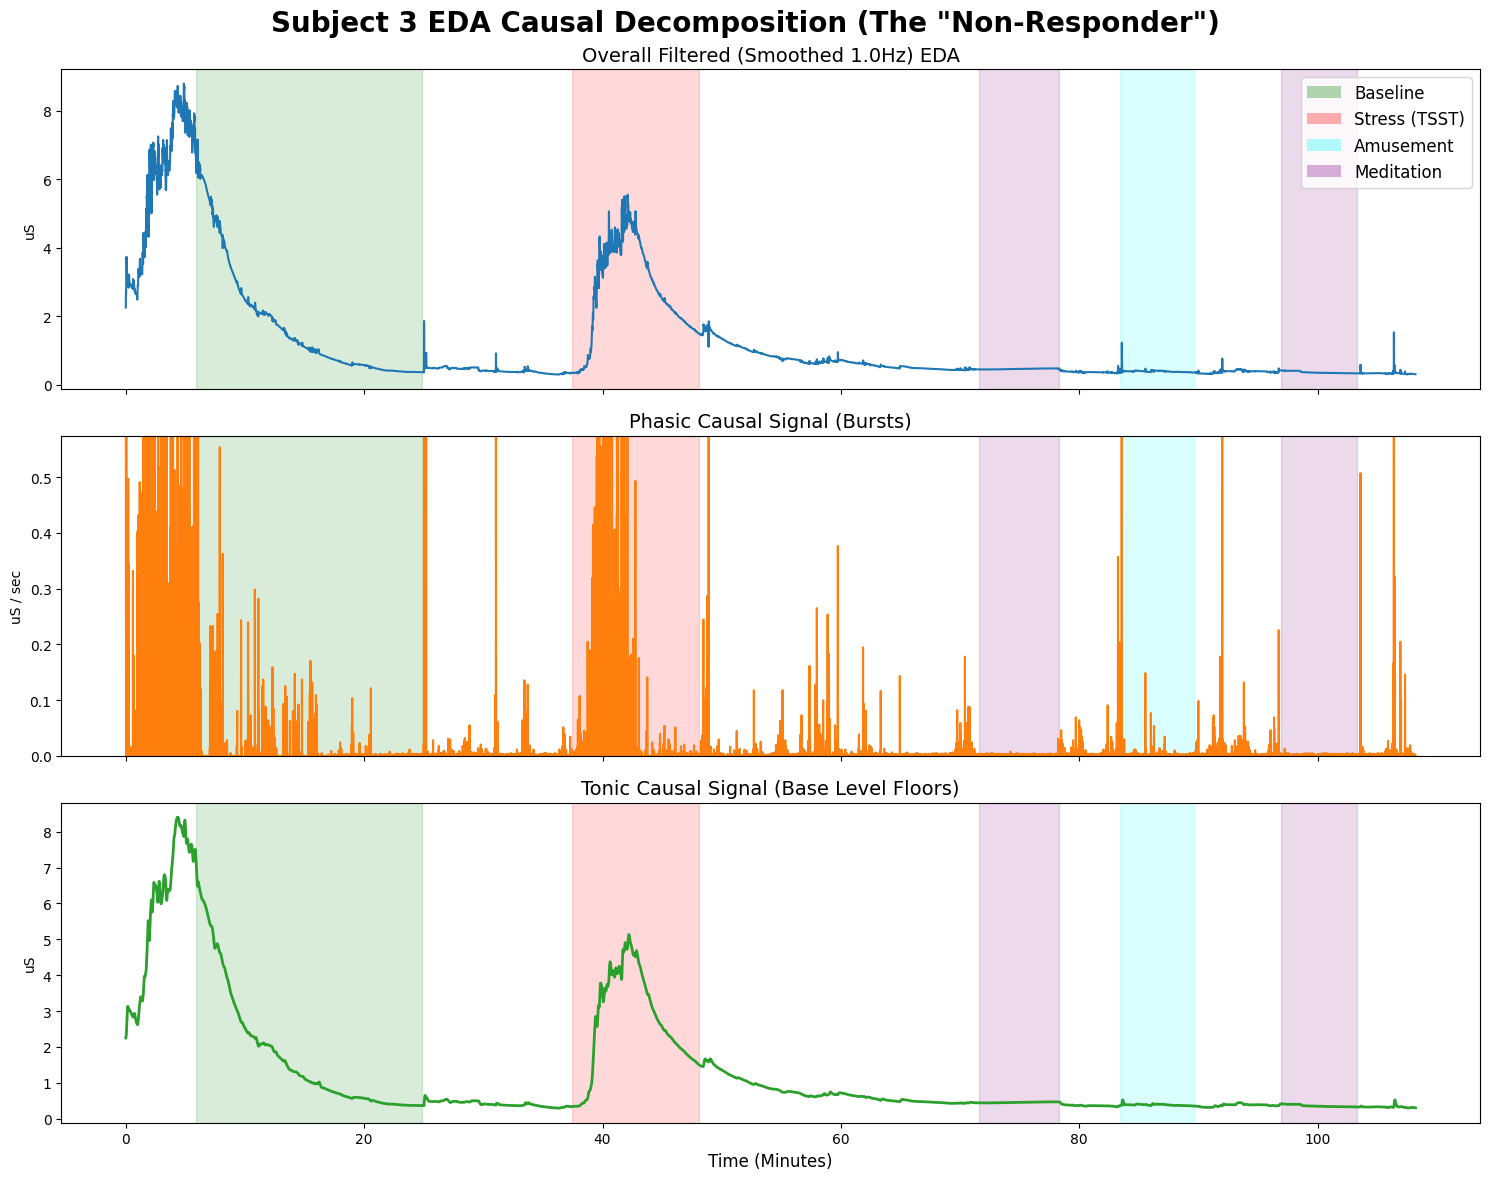

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy.signal import butter, lfilter, lfilter_zi
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# Hardcoded path directly to your WESAD S3 data
file_path = r"C:\Users\gloriosog\OneDrive - Milwaukee School of Engineering\Year 4 Courses\Semester 1\Senior Design\WESAD Dataset\WESAD2\WESAD\S3\S3.pkl"

print("Loading Subject 3 (S3) Data...")
with open(file_path, 'rb') as f:
    data = pickle.load(f, encoding='latin1')

raw_eda = data['signal']['wrist']['EDA'].flatten()
labels = data['label'].flatten()
fs = 4.0        # Wrist EDA is 4Hz
fs_label = 700.0 # Labels are 700Hz

nyq = 0.5 * fs
time_eda = np.arange(len(raw_eda)) / fs / 60.0  # Converted to Minutes

# ---------------------------------------------------------
# Your Exact Causal Filter Code
# ---------------------------------------------------------
# Step 1: Artifact Smoothing (1.0 Hz Lowpass)
b1, a1 = butter(1, 1.0 / nyq, btype='low')
zi1 = lfilter_zi(b1, a1) * raw_eda[0]
smoothed_eda, _ = lfilter(b1, a1, raw_eda, zi=zi1)

# Step 2: Tonic Extraction (0.05 Hz Lowpass)
b2, a2 = butter(2, 0.05 / nyq, btype='low')
zi2 = lfilter_zi(b2, a2) * smoothed_eda[0]
tonic_causal, _ = lfilter(b2, a2, smoothed_eda, zi=zi2)

# Step 3: Phasic Extraction (Rate of Change)
dt = 1.0 / fs
derivative = np.gradient(smoothed_eda, dt)
phasic_causal = np.maximum(0, derivative)

# ---------------------------------------------------------
# Plotting Configuration with Beautiful Color Overlays
# ---------------------------------------------------------
print("Generating Physiological Subplots...")
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
fig.suptitle('Subject 3 EDA Causal Decomposition (The "Non-Responder")', fontsize=20, fontweight='bold')

# Subplot 1: Overall Filtered (Smoothed)
ax1.plot(time_eda, smoothed_eda, color='#1f77b4', linewidth=1.5, label='Smoothed EDA')
ax1.set_title('Overall Filtered (Smoothed 1.0Hz) EDA', fontsize=14)
ax1.set_ylabel('uS')

# Subplot 2: Phasic Causal
ax2.plot(time_eda, phasic_causal, color='#ff7f0e', linewidth=1.5)
ax2.set_title('Phasic Causal Signal (Bursts)', fontsize=14)
ax2.set_ylabel('uS / sec')
ax2.set_ylim(0, np.percentile(phasic_causal, 99.5)) # Clip any wild sensor transient spikes

# Subplot 3: Tonic Causal
ax3.plot(time_eda, tonic_causal, color='#2ca02c', linewidth=2)
ax3.set_title('Tonic Causal Signal (Base Level Floors)', fontsize=14)
ax3.set_ylabel('uS')
ax3.set_xlabel('Time (Minutes)', fontsize=12)

# --- Add Label Overlays ---
colors = {
    1: 'green',        # Baseline
    2: 'red',          # STRESS
    3: 'cyan',         # Amusement
    4: 'purple',       # Meditation
}

# Downsample labels to 4Hz to match EDA perfectly
labels_4hz = labels[::int(fs_label/fs)] 
min_len = min(len(labels_4hz), len(time_eda))

# Detect when the WESAD human-annotated state changes
changes = np.where(np.diff(labels_4hz[:min_len]) != 0)[0]
start_idx = 0

for t_idx in changes:
    lbl_val = labels_4hz[start_idx]
    if lbl_val in colors:
        c = colors[lbl_val]
        ax1.axvspan(time_eda[start_idx], time_eda[t_idx], color=c, alpha=0.15)
        ax2.axvspan(time_eda[start_idx], time_eda[t_idx], color=c, alpha=0.15)
        ax3.axvspan(time_eda[start_idx], time_eda[t_idx], color=c, alpha=0.15)
    start_idx = t_idx + 1

# Final block trailing cap
lbl_val = labels_4hz[start_idx]
if lbl_val in colors:
    c = colors[lbl_val]
    ax1.axvspan(time_eda[start_idx], time_eda[min_len-1], color=c, alpha=0.15)
    ax2.axvspan(time_eda[start_idx], time_eda[min_len-1], color=c, alpha=0.15)
    ax3.axvspan(time_eda[start_idx], time_eda[min_len-1], color=c, alpha=0.15)

# Custom Legend
legend_elements = [
    Patch(facecolor='green', alpha=0.3, label='Baseline'),
    Patch(facecolor='red', alpha=0.3, label='Stress (TSST)'),
    Patch(facecolor='cyan', alpha=0.3, label='Amusement'),
    Patch(facecolor='purple', alpha=0.3, label='Meditation')
]
ax1.legend(handles=legend_elements, loc='upper right', fontsize=12)

plt.tight_layout()
fig.subplots_adjust(top=0.93)
plt.show()


## The "Corrupted" Baseline
Right at the beginning of the Green Baseline window (around minutes 5 to 10), Subject 3 has a colossal EDA spike. Their Tonic signal shoots all the way up to 8.5 uS, and their Phasic bursts are violently firing. They were either physically moving, adjusting the sensor, or practically having a panic attack while they were supposed to be "resting."

It looked at the Stress window (5.0 uS).
It compared it to the Baseline window (8.5 uS).
It calculated that Subject 3 was actually calmer during the Trier Social Stress Test than they were during their Baseline period.
It confidently predicted: "Non-Stress".

# Evaluate Movement Data of Subject 3

Loading Subject 3 (S3) ACC Data...
Generating ACC Movement Subplots...


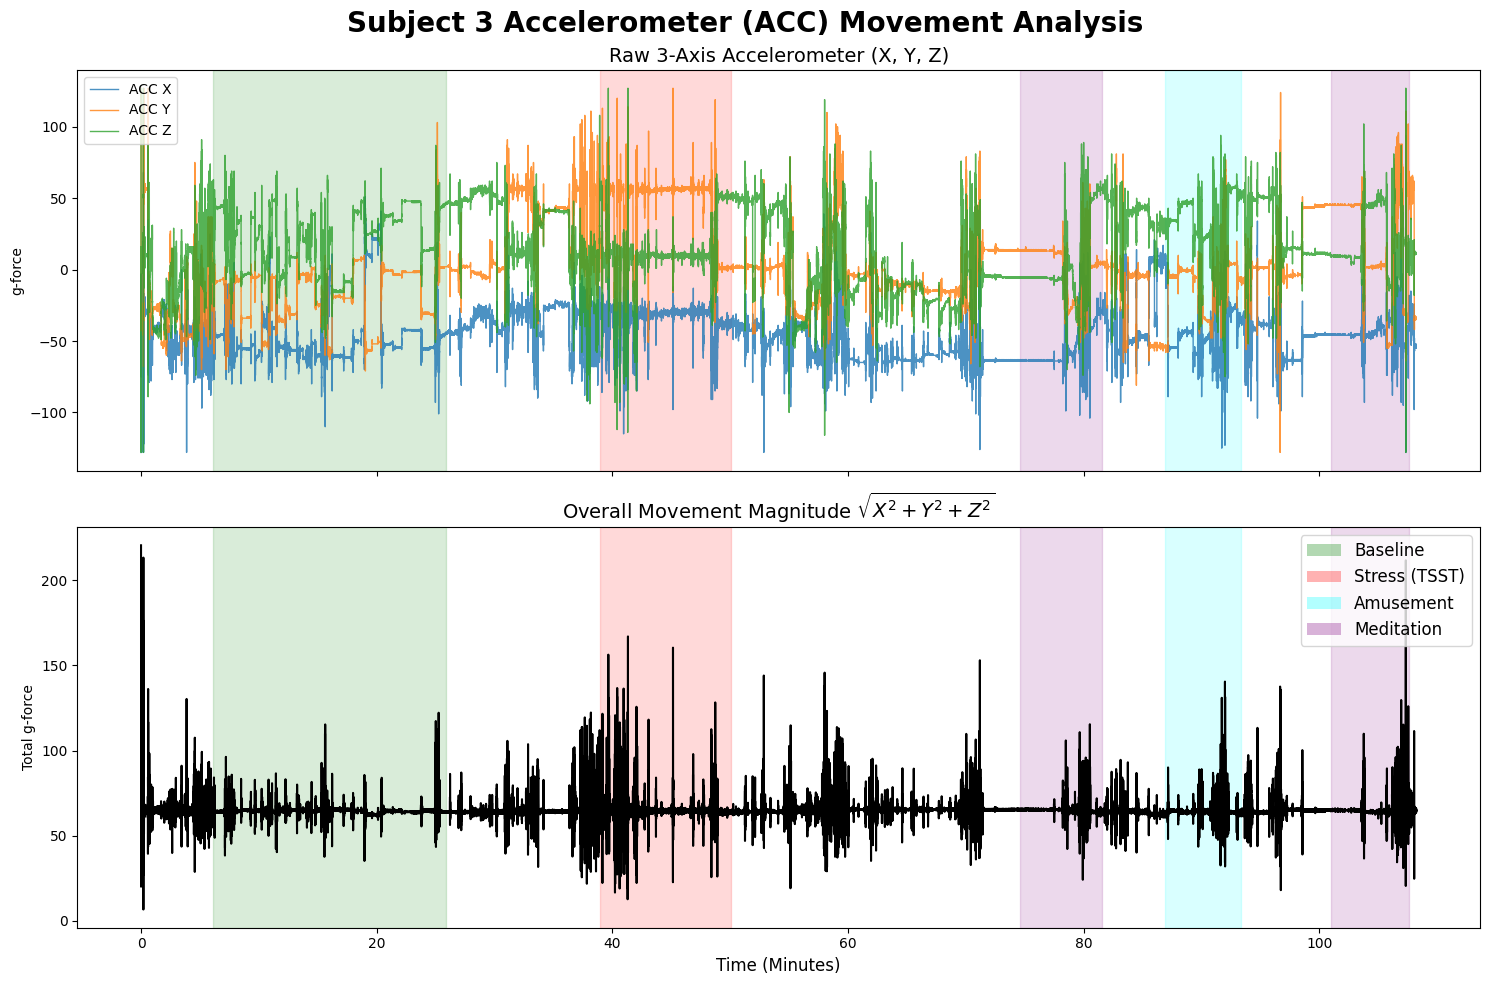

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# WESAD S3 Path
file_path = r"C:\Users\gloriosog\OneDrive - Milwaukee School of Engineering\Year 4 Courses\Semester 1\Senior Design\WESAD Dataset\WESAD2\WESAD\S3\S3.pkl"

print("Loading Subject 3 (S3) ACC Data...")
with open(file_path, 'rb') as f:
    data = pickle.load(f, encoding='latin1')

# Extract Wrist ACC and Labels
raw_acc = data['signal']['wrist']['ACC']  # Shape: (N, 3) for X, Y, Z
labels = data['label'].flatten()

fs_acc = 32.0      # Wrist ACC is sampled at 32Hz
fs_label = 700.0   # Labels are 700Hz

time_acc = np.arange(len(raw_acc)) / fs_acc / 60.0  # Converted to Minutes

# Calculate ACC Magnitude = sqrt(x^2 + y^2 + z^2)
# This gives us a single line showing total 3D physical movement
acc_magnitude = np.linalg.norm(raw_acc, axis=1)

# ---------------------------------------------------------
# Plotting Configuration
# ---------------------------------------------------------
print("Generating ACC Movement Subplots...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
fig.suptitle('Subject 3 Accelerometer (ACC) Movement Analysis', fontsize=20, fontweight='bold')

# Subplot 1: Raw 3-Axis ACC
ax1.plot(time_acc, raw_acc[:, 0], color='#1f77b4', linewidth=1.0, label='ACC X', alpha=0.8)
ax1.plot(time_acc, raw_acc[:, 1], color='#ff7f0e', linewidth=1.0, label='ACC Y', alpha=0.8)
ax1.plot(time_acc, raw_acc[:, 2], color='#2ca02c', linewidth=1.0, label='ACC Z', alpha=0.8)
ax1.set_title('Raw 3-Axis Accelerometer (X, Y, Z)', fontsize=14)
ax1.set_ylabel('g-force')
ax1.legend(loc='upper left')

# Subplot 2: Overall Magnitude
ax2.plot(time_acc, acc_magnitude, color='black', linewidth=1.5, label='ACC Magnitude')
ax2.set_title(r'Overall Movement Magnitude $\sqrt{X^2 + Y^2 + Z^2}$', fontsize=14)
ax2.set_ylabel('Total g-force')
ax2.set_xlabel('Time (Minutes)', fontsize=12)

# --- Add Label Overlays ---
colors = {
    1: 'green',        # Baseline
    2: 'red',          # STRESS
    3: 'cyan',         # Amusement
    4: 'purple',       # Meditation
}

# Downsample labels to 32Hz to match ACC perfectly
labels_32hz = labels[::int(fs_label/fs_acc)] 
min_len = min(len(labels_32hz), len(time_acc))

changes = np.where(np.diff(labels_32hz[:min_len]) != 0)[0]
start_idx = 0

for t_idx in changes:
    lbl_val = labels_32hz[start_idx]
    if lbl_val in colors:
        c = colors[lbl_val]
        ax1.axvspan(time_acc[start_idx], time_acc[t_idx], color=c, alpha=0.15)
        ax2.axvspan(time_acc[start_idx], time_acc[t_idx], color=c, alpha=0.15)
    start_idx = t_idx + 1

# Final block trailing cap
lbl_val = labels_32hz[start_idx]
if lbl_val in colors:
    c = colors[lbl_val]
    ax1.axvspan(time_acc[start_idx], time_acc[min_len-1], color=c, alpha=0.15)
    ax2.axvspan(time_acc[start_idx], time_acc[min_len-1], color=c, alpha=0.15)

# Custom Legend
legend_elements = [
    Patch(facecolor='green', alpha=0.3, label='Baseline'),
    Patch(facecolor='red', alpha=0.3, label='Stress (TSST)'),
    Patch(facecolor='cyan', alpha=0.3, label='Amusement'),
    Patch(facecolor='purple', alpha=0.3, label='Meditation')
]
ax2.legend(handles=legend_elements, loc='upper right', fontsize=12)

plt.tight_layout()
fig.subplots_adjust(top=0.92)
plt.show()


The Sensor was NOT Broken (The Baseline was Real)

Notice how on the bottom Accelerometer graph. Notice how the black line is relatively flat and tight? Subject 3 was sitting completely still. Now remember the EDA graph we looked at earlier? During those exact same 5 to 10 minutes, Subject 3 had a massive 8.5 uS sweat spike.

Conclusion: This was not a loose strap or a bumped sensor (otherwise the ACC graph would be spiking wildly). Subject 3 was sitting perfectly still but was having a massive, genuine physiological panic or arousal response while reading the magazines they were supposed to be "resting" to. Their Baseline was absolutely real, just highly anxious.

Now look at the Red Stress window (minutes 38 to 48). The black Accelerometer line is thrashing violently! They are standing up, shifting around, and speaking (this is the Trier Social Stress Test). However, their actual physiological sweat response (from the first graph) during this chaotic movement was actually lower than when they were sitting perfectly still earlier!

# The Final Verdict:
Subject 3 is a genuine physiological anomaly—they were actively more terrified/anxious/aroused during the "Resting phase" than they were during the actual stressful task!

# NO EDA FEATURES

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import classification_report, accuracy_score, recall_score, precision_score
import warnings
warnings.filterwarnings('ignore')

# -------------------------------------------------------
# Load Dataset
# -------------------------------------------------------
df = pd.read_csv('causal_features_stride60.csv')

# Label: WESAD label 2 = Stress. All others (1=Baseline, 3=Amusement, 4=Meditation) = Non-Stress
df['target'] = (df['raw_label'] == 2).astype(int)

print(f"Dataset Shape: {df.shape}")
print("\nLabel Distribution:")
print(df['target'].value_counts().rename({0: 'Non-Stress', 1: 'Stress'}))

X_full = df.drop(columns=['raw_label', 'label', 'time_end_sec', 'subject_id', 'target'])
y = df['target']
groups = df['subject_id']

# -------------------------------------------------------
# No-EDA Feature Set (12 features)
# -------------------------------------------------------
no_eda_features = [
    # Temperature
    'z_temp_median', 'z_temp_slope', 'raw_temp_mean',
    # Time-Domain HRV
    'z_hrv_rmssd', 'z_hrv_median_rr', 'z_hrv_pnn50', 'raw_hrv_pnn50', 'z_hrv_mean_hr',
    # Freq-Domain HRV
    'z_hrv_hf_power',
    # Activity Tripwires
    'acc_magnitude_mean', 'acc_magnitude_max', 'acc_magnitude_std'
]

X = X_full[no_eda_features]

print(f"\nFeatures used: {len(no_eda_features)}")
print(f"Total Subjects (LOSO Folds): {groups.nunique()}")

# -------------------------------------------------------
# LOSO Cross-Validation
# -------------------------------------------------------
logo = LeaveOneGroupOut()
y_true_all = []
y_pred_all = []
subject_metrics = []

print("\nStarting No-EDA LOSO Cross-Validation...\n")

for fold_idx, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), 1):
    held_out_subject = groups.iloc[test_idx].unique()[0]

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

    model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss'
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    y_true_all.extend(y_test)
    y_pred_all.extend(preds)

    acc = accuracy_score(y_test, preds)
    stress_recall = recall_score(y_test, preds, pos_label=1, zero_division=0)
    stress_precision = precision_score(y_test, preds, pos_label=1, zero_division=0)
    subject_metrics.append({
        'Subject': held_out_subject,
        'Accuracy': acc,
        'Stress Recall': stress_recall,
        'Stress Precision': stress_precision
    })

    print(f"  [{fold_idx:02d}] {held_out_subject} -> Accuracy: {acc*100:.1f}%, Stress Recall: {stress_recall*100:.1f}%")

# -------------------------------------------------------
# Results
# -------------------------------------------------------
print("\n=== No-EDA LOSO Results ===")
print(classification_report(y_true_all, y_pred_all, target_names=['Non-Stress', 'Stress']))

metrics_df = pd.DataFrame(subject_metrics).set_index('Subject')
metrics_df['Accuracy'] = (metrics_df['Accuracy'] * 100).round(1).astype(str) + '%'
metrics_df['Stress Recall'] = (metrics_df['Stress Recall'] * 100).round(1).astype(str) + '%'
metrics_df['Stress Precision'] = (metrics_df['Stress Precision'] * 100).round(1).astype(str) + '%'
print("\n=== Per-Subject Breakdown ===")
print(metrics_df.to_string())
